<a href="https://colab.research.google.com/github/AnkitMana/Lyapunov-Fractal-Visualisation/blob/main/Lyapunov_Fractal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LYAPUNOV FRACTAL

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numba
from numba import jit
import math



For this case we using the function:

    x(n+1)= b*sin^2( xn + r)

## Defining the parameters and function


Here the function parameters for an initial case were taken to study how the function lyapunov function behaves and what would be its lyapunov exponent's value

In [2]:
b = 4
r = 2.16
max_len = 10000 # the number of points for which we calculating the function iteratively
x0 = np.pi/8 # initial value we are taking

Defining the function

In [3]:
@jit(nopython=True)
def fn(xn, r):
  xn1 = b*math.pow(np.sin(xn+r),2)
  return xn1

Calculating the Lyapunov Exponent

In [4]:
@jit(nopython=True)
def lambda_fn(y,r):
  lambda_num = np.average(np.log(np.abs(b*np.sin(2*(y+r)))))
  return lambda_num

Calculating the values

In [5]:
x = np.arange(0,max_len-1)
y = [x0,]
for i in range(len(x)-1):
  x1 = fn(y[len(y)-1],r)
  y.append(x1)
y = np.array(y)

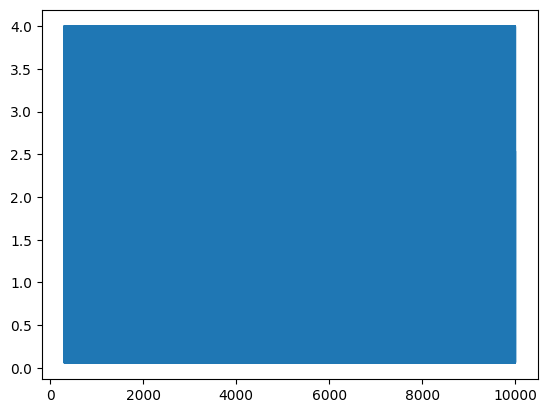

In [6]:
# removing the more unstable region to get a good lyapunov fractal
stablility = 300
plt.plot(x[stablility:],y[stablility:])
plt.show()

In [7]:
print(lambda_fn(y,r))

-0.042825636186133755


## Plotting the Lyapunov Exponent
Here we are taking a range of r values starting from 1 to 1000 with a progression of 0.01 so 100k points and finding the lyapunov exponent for each. And to find the lyapunov exponent we using a sequence of 10000 points to calculate the lyapunov exponent

In [8]:
r1 = np.arange(1,1000, 0.01)# defining the range of r

In [9]:
@jit(nopython=True)
def calc_lyapunov_exp(r):
  y = [x0,]
  for i in range(max_len):
    x1 = fn(y[len(y)-1],r)
    y.append(x1)
  y = np.array(y[stablility:])
  return lambda_fn(y,r)

In [10]:
lyapunov_range = []
for i in range(len(r1)):
  lyapunov_range.append(calc_lyapunov_exp(r1[i]))
lyapunov_range = np.array(lyapunov_range)

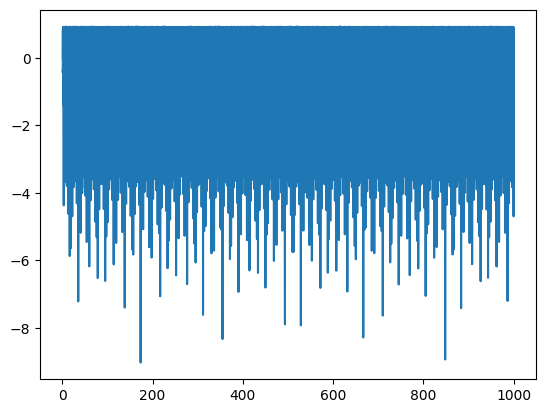

In [11]:
plt.plot(r1,lyapunov_range)
plt.show()

## Task
Generate a 2D plot where the x-axis represents values of `r2` from -3 to 3, the y-axis represents values of `r1` from -6 to 6, and the color of each point on the plot corresponds to the Lyapunov exponent calculated for a sequence generated using an alternating pattern of 6 iterations with `r1` and 6 iterations with `r2`.

To calculate the lyapunov lambda for each point on the map based on the A6B6 pattern.

In [27]:
@jit(nopython=True)
def calc_lyapunov(ra, rb, b_const, max_len, settle_len):
    x = 0.5
    total_lambda = 0.0

    for i in range(max_len):
        # Sequence: AAAAAABBBBBB (A6B6)
        # ra is X-coordinate, rb is Y-coordinate
        r = ra if (i % 12) < 6 else rb

        # Iteration
        x = b_const * (np.sin(x + r)**2)

        # Stability Calculation (Lyapunov Exponent)
        if i >= settle_len:
            deriv = np.abs(b_const * np.sin(2 * (x + r)))
            total_lambda += np.log(deriv + 1e-10)

    return total_lambda / (max_len - settle_len)

Generating a matrix for all the points on the map based on the pattern

In [28]:
from numba import prange

@jit(nopython=True, parallel=True)
def generate_web(ra_vals, rb_vals, b_const):
    size = len(ra_vals)
    matrix = np.empty((size, size))
    for i in prange(size):
        for j in range(size):
            matrix[i, j] = calc_lyapunov(ra_vals[j], rb_vals[i], b_const, 2000, 500)
    return matrix


Running the code

In [37]:
res = 2000 # the resolution of the image handled by this. increasing this gets a finer image
ra_axis = np.linspace(0.75,1.35, res)# x axis
rb_axis = np.linspace(0.75,1.35, res)# y axis

fractal_matrix = generate_web(ra_axis, rb_axis, 3.85)

## Result

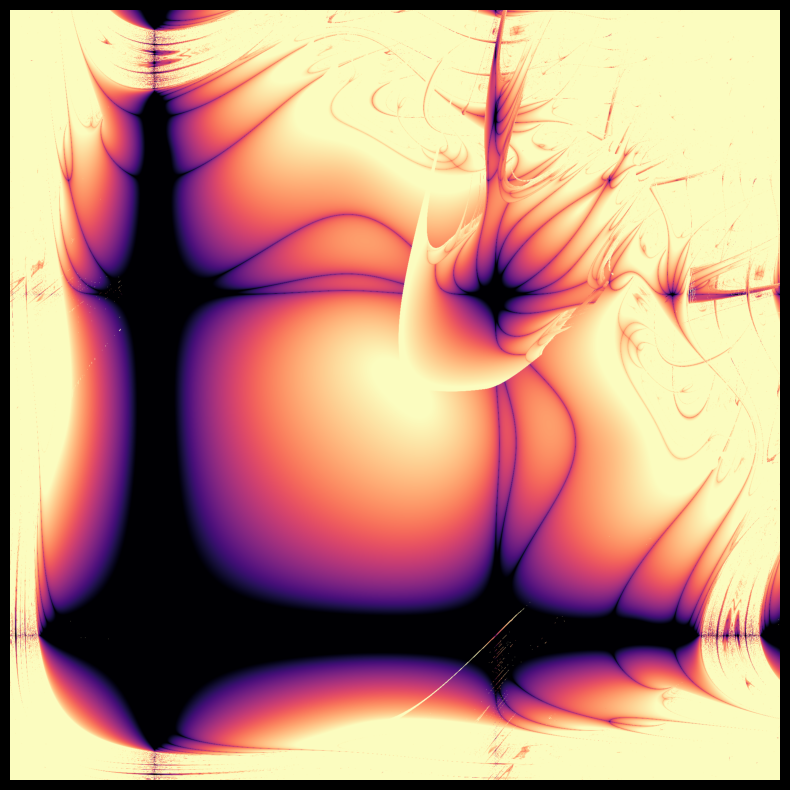

In [39]:
plt.figure(figsize=(10, 10), facecolor='black')
plt.imshow(fractal_matrix,
           extent=[0, np.pi, 0, np.pi],
           origin='lower',
           cmap='magma',
           vmin=-1.2, vmax=-0.05)

plt.axis('off')
plt.show()